# Decoded Plots

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pathlib import Path


csv_path = Path("../../output/decoded.csv")
df = pd.read_csv(csv_path)

In this set, `volume_noise` is fixed at `0.01`.
Each message is evaluated across combinations of `frequency` and `volume_gain_data`.
The plots below fix one message at a time to show how frequency and data volume affect error rate.

## Message-wise Frequency and Data Volume Plots

In [2]:
from pandas import DataFrame
import numpy as np


def format_float_label(value: float, decimals: int = 2) -> str:
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


def shorten_message(text: str, max_len: int = 70) -> str:
    clean = " ".join(str(text).split())
    if len(clean) <= max_len:
        return clean
    return clean[: max_len - 3] + "..."


def prepare_plot_df(df: DataFrame) -> DataFrame:
    plot_df = df.copy()

    if "status" in plot_df.columns:
        plot_df = plot_df[plot_df["status"].astype(str).str.lower() == "success"]

    for col in ["frequency", "volume_gain_data", "error_rate"]:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    plot_df = plot_df.dropna(subset=["message", "frequency", "volume_gain_data", "error_rate"])
    plot_df["message_label"] = plot_df["message"].astype(str)
    return plot_df


def plot_error_rate_heatmaps_by_message(df: DataFrame) -> None:
    plot_df = prepare_plot_df(df)
    messages = plot_df["message_label"].drop_duplicates().tolist()

    for message in messages:
        subset = plot_df[plot_df["message_label"] == message]
        pivot = (
            subset.pivot_table(
                index="volume_gain_data",
                columns="frequency",
                values="error_rate",
                aggfunc="mean",
            )
            .sort_index()
            .sort_index(axis=1)
        )

        if pivot.empty:
            continue

        fig, ax = plt.subplots(figsize=(14, 5))
        image = ax.imshow(
            pivot.values,
            cmap="viridis",
            aspect="auto",
            origin="lower",
            vmin=0,
            vmax=1,
        )

        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([str(int(v)) for v in pivot.columns], rotation=45, ha="right")

        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([format_float_label(v, decimals=3) for v in pivot.index])

        ax.set_xlabel("Frequency")
        ax.set_ylabel("Volume Gain Data")
        ax.set_title(f"Error Rate Heatmap | Message: {shorten_message(message)}")

        color_bar = plt.colorbar(image, ax=ax)
        color_bar.set_label("Error Rate")

        plt.tight_layout()
        plt.show()


def plot_error_rate_vs_frequency_by_message(df: DataFrame) -> None:
    plot_df = prepare_plot_df(df)
    messages = plot_df["message_label"].drop_duplicates().tolist()

    for message in messages:
        subset = plot_df[plot_df["message_label"] == message]
        if subset.empty:
            continue

        fig, ax = plt.subplots(figsize=(14, 5))
        for frequency, grouped in subset.groupby("frequency"):
            grouped = grouped.sort_values("volume_gain_data")
            ax.plot(
                grouped["volume_gain_data"],
                grouped["error_rate"],
                marker="o",
                linewidth=2,
                markersize=5,
                label=f"Freq: {int(frequency)}",
            )

        ax.set_xlabel("Volume Gain Data")
        ax.set_ylabel("Error Rate")
        ax.set_ylim(0, 1)
        ax.set_title(f"Error Rate vs Volume Gain Data | Message: {shorten_message(message)}")
        ax.legend(title="Frequency", ncol=3)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


def plot_error_rate_vs_volume_by_message(df: DataFrame) -> None:
    plot_df = prepare_plot_df(df)
    messages = plot_df["message_label"].drop_duplicates().tolist()

    for message in messages:
        subset = plot_df[plot_df["message_label"] == message]
        if subset.empty:
            continue

        fig, ax = plt.subplots(figsize=(14, 5))
        for frequency, grouped in subset.groupby("frequency"):
            grouped = grouped.sort_values("volume_gain_data")
            ax.plot(
                grouped["volume_gain_data"],
                grouped["error_rate"],
                marker="o",
                linewidth=2,
                markersize=5,
                label=f"Freq: {int(frequency)}",
            )

        ax.set_xlabel("Volume Gain Data")
        ax.set_ylabel("Error Rate")
        ax.set_ylim(0, 1)
        ax.set_title(f"Error Rate vs Volume Gain Data | Message: {shorten_message(message)}")
        ax.legend(title="Frequency", ncol=3)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Error Rate Heatmaps by Message

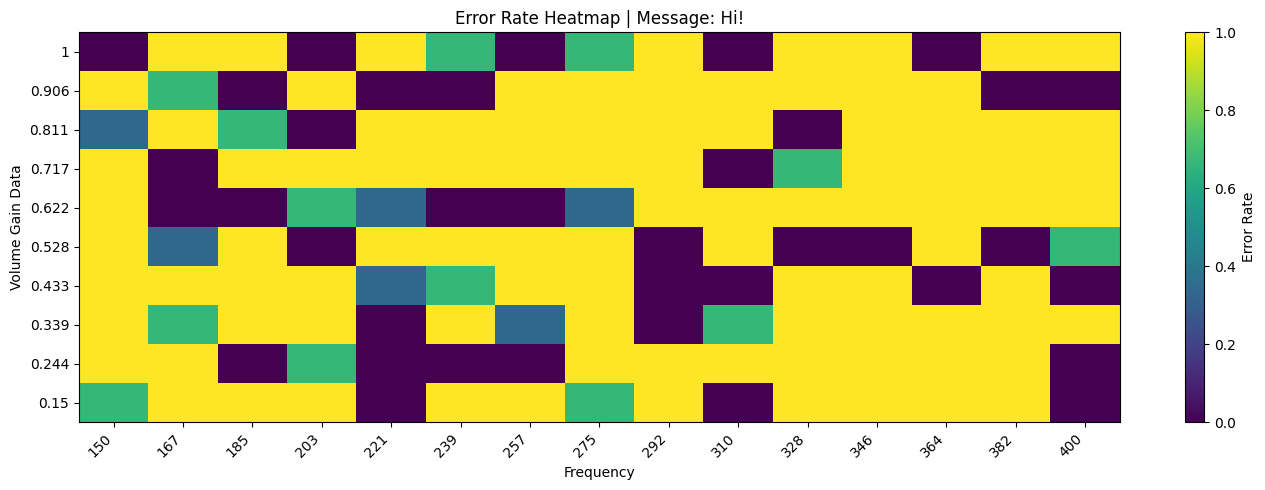

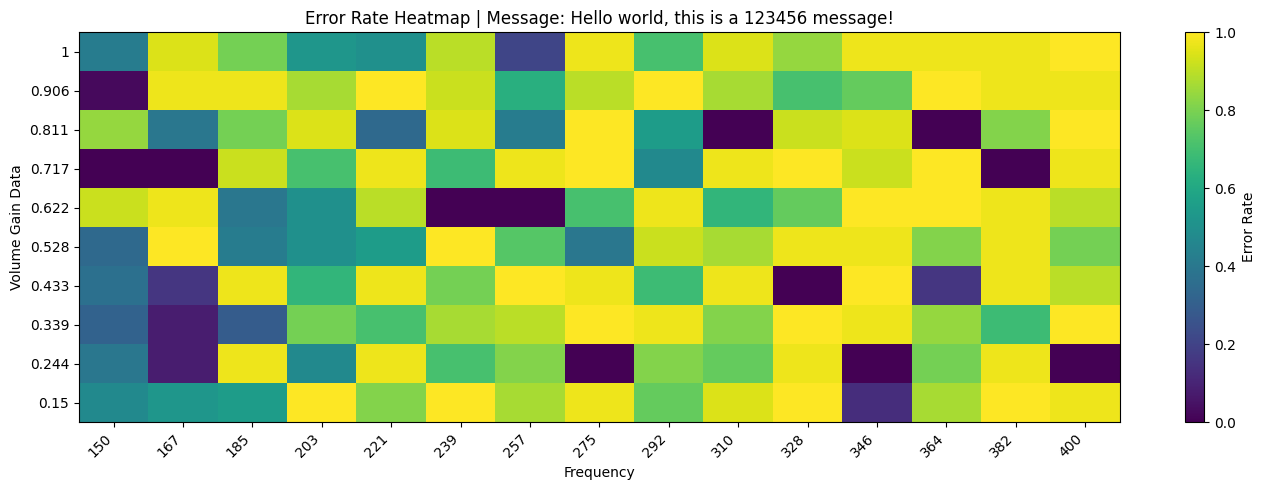

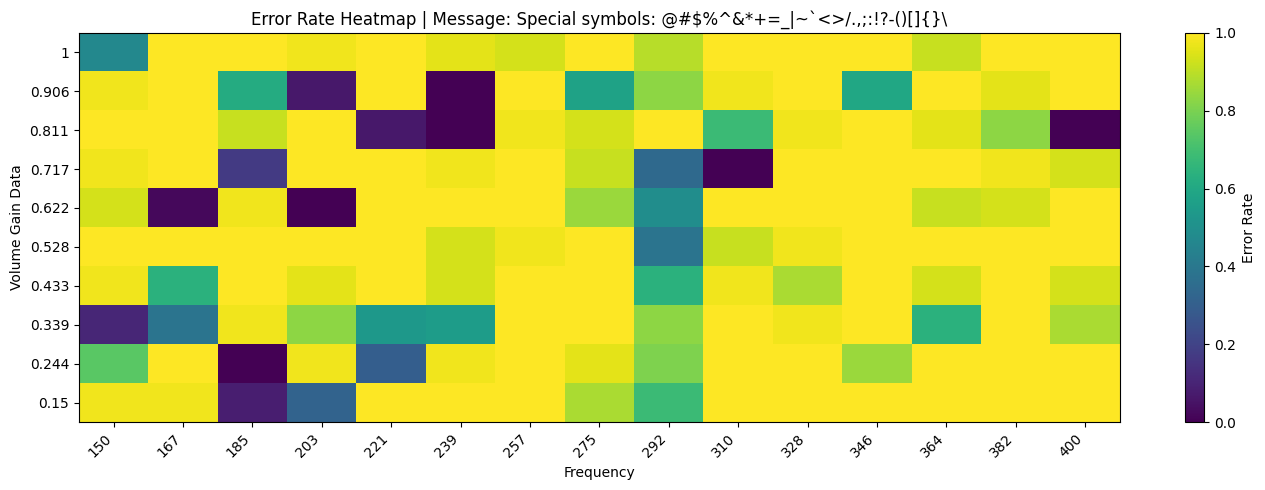

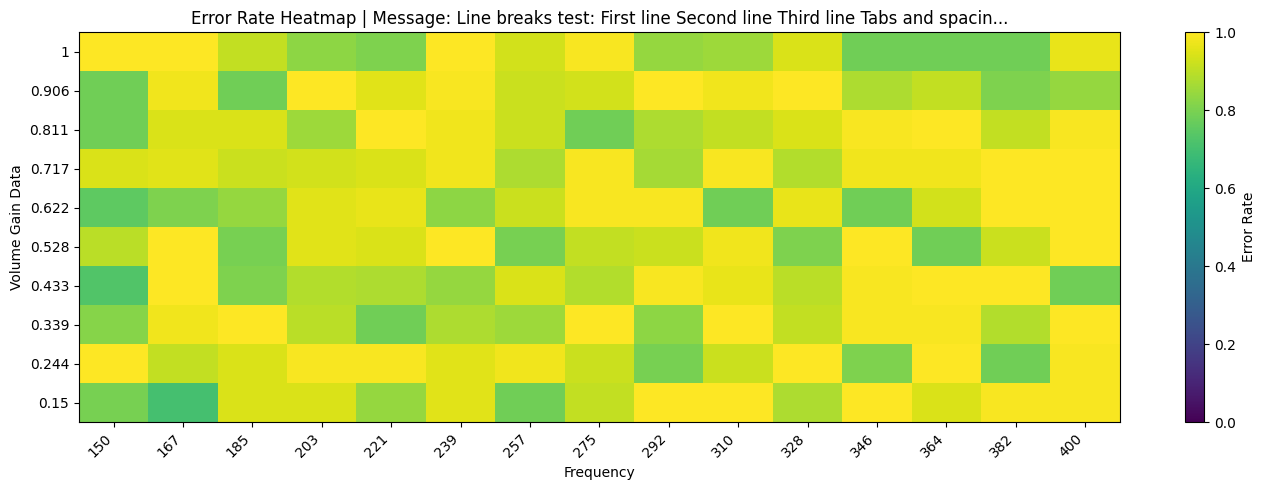

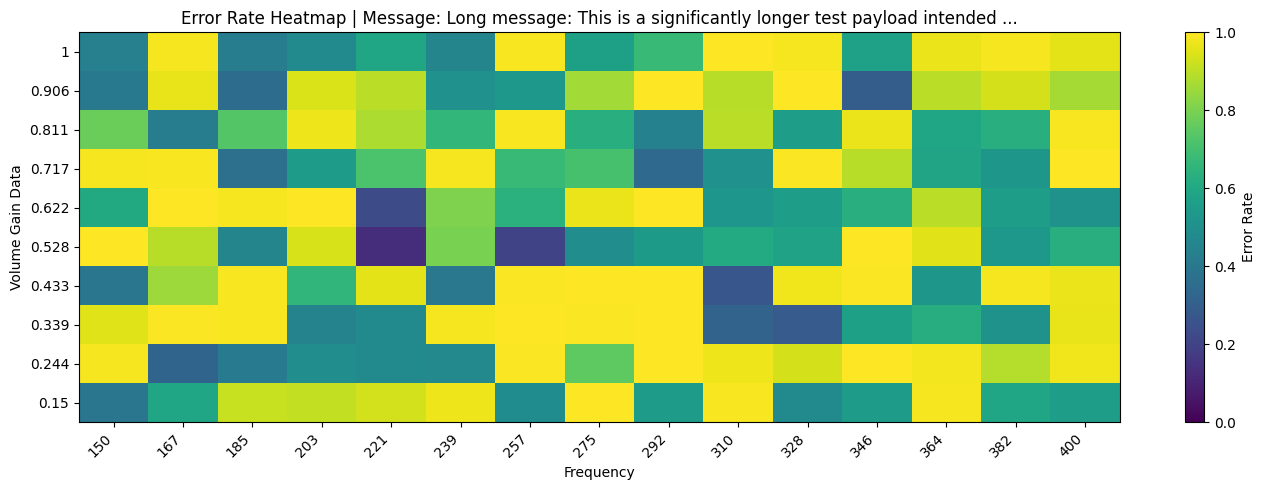

In [3]:
plot_error_rate_heatmaps_by_message(df)

## Error Rate vs Frequency (one chart per message)

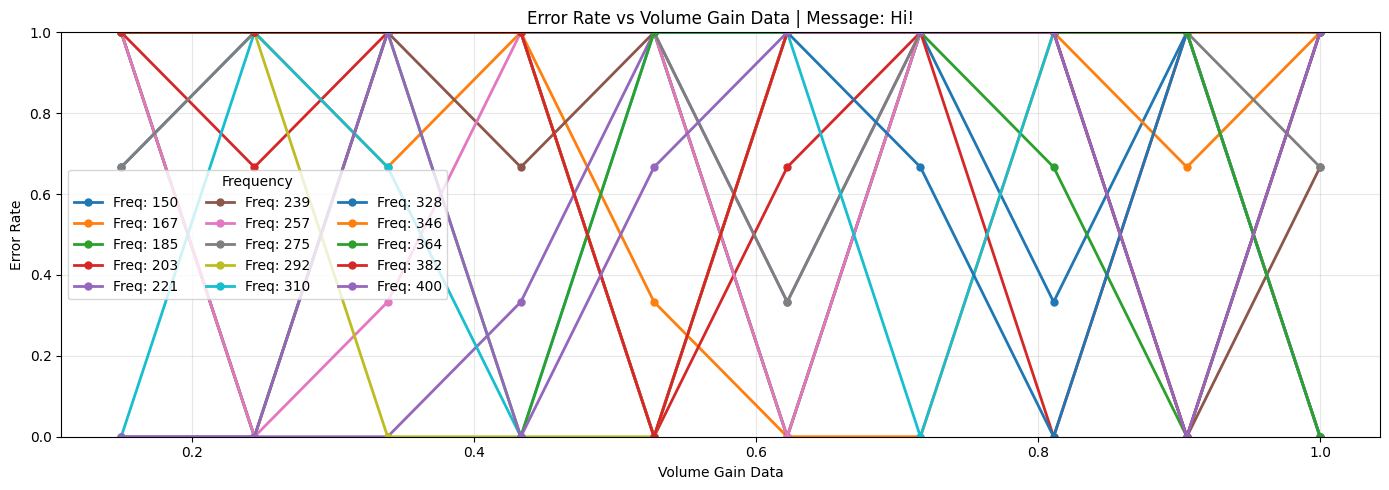

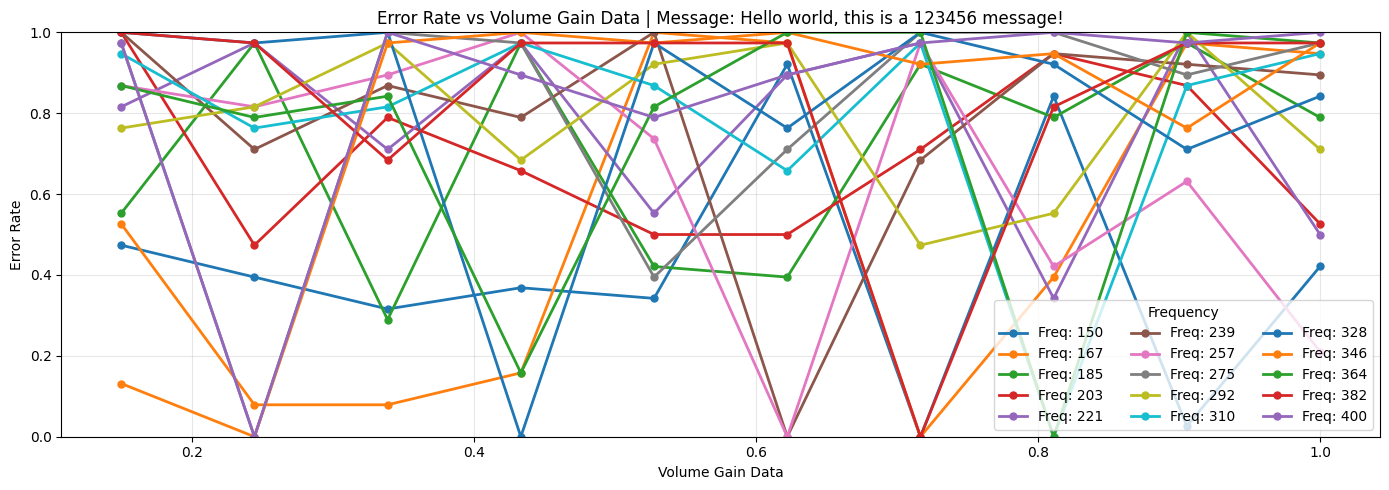

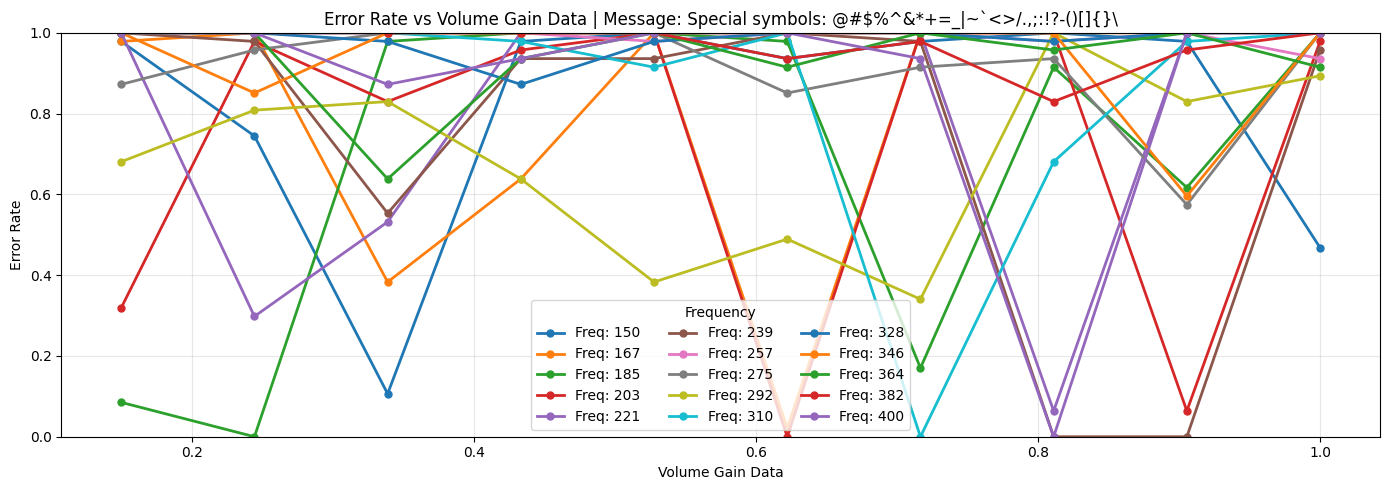

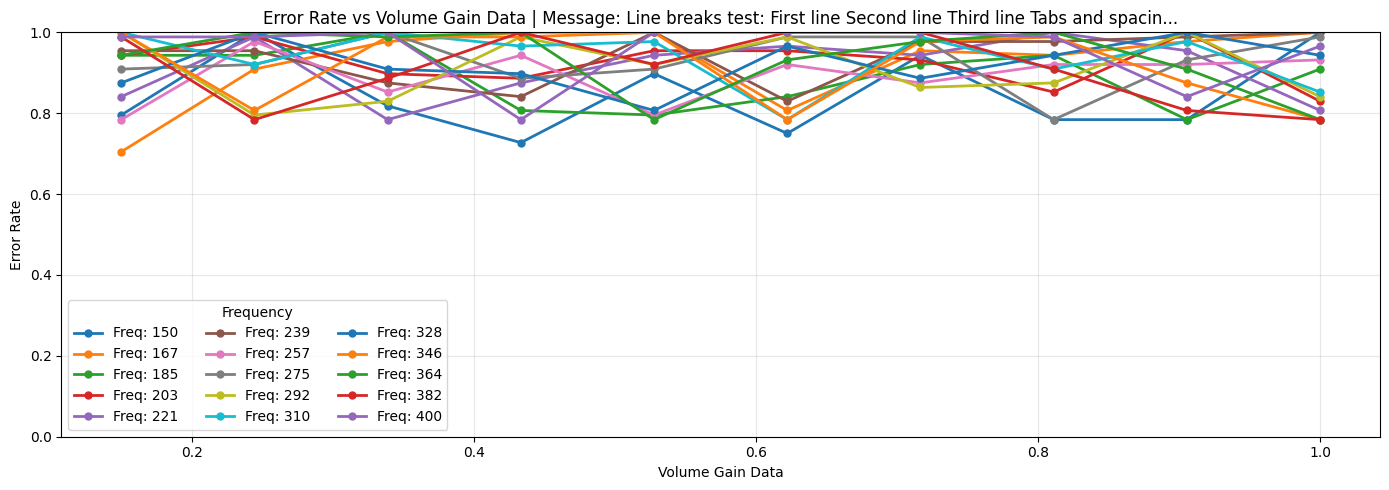

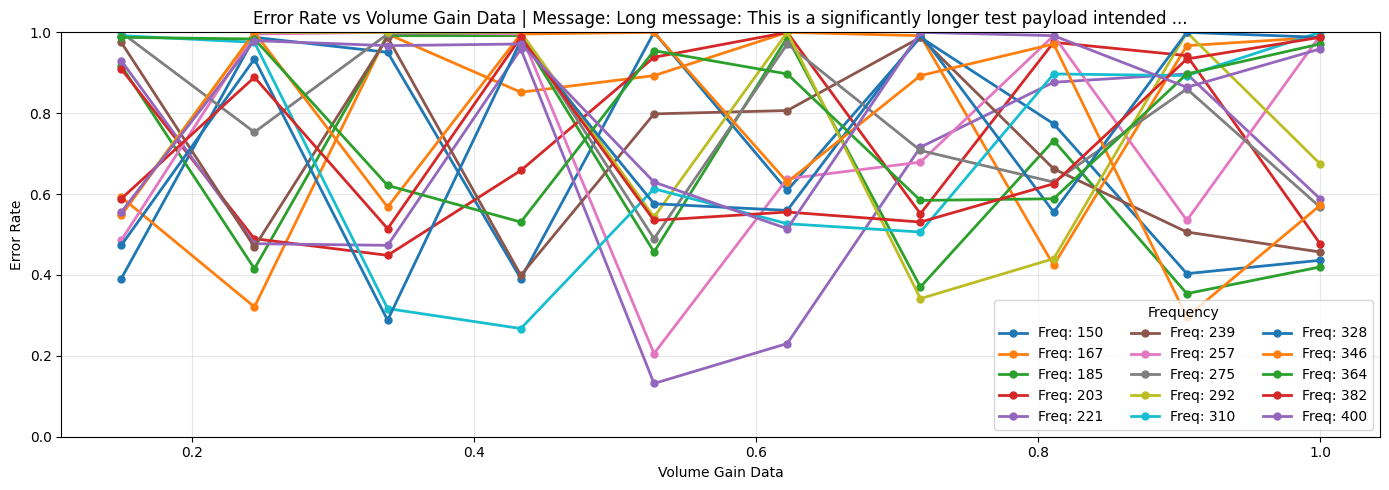

In [4]:
plot_error_rate_vs_frequency_by_message(df)

## Error Rate vs Data Volume (one chart per message)

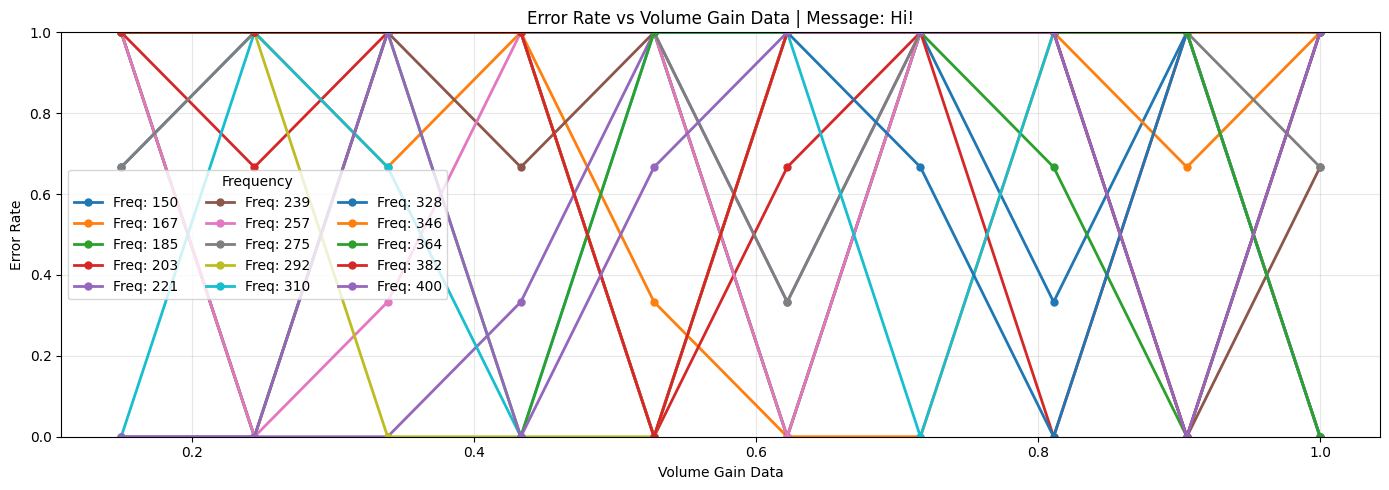

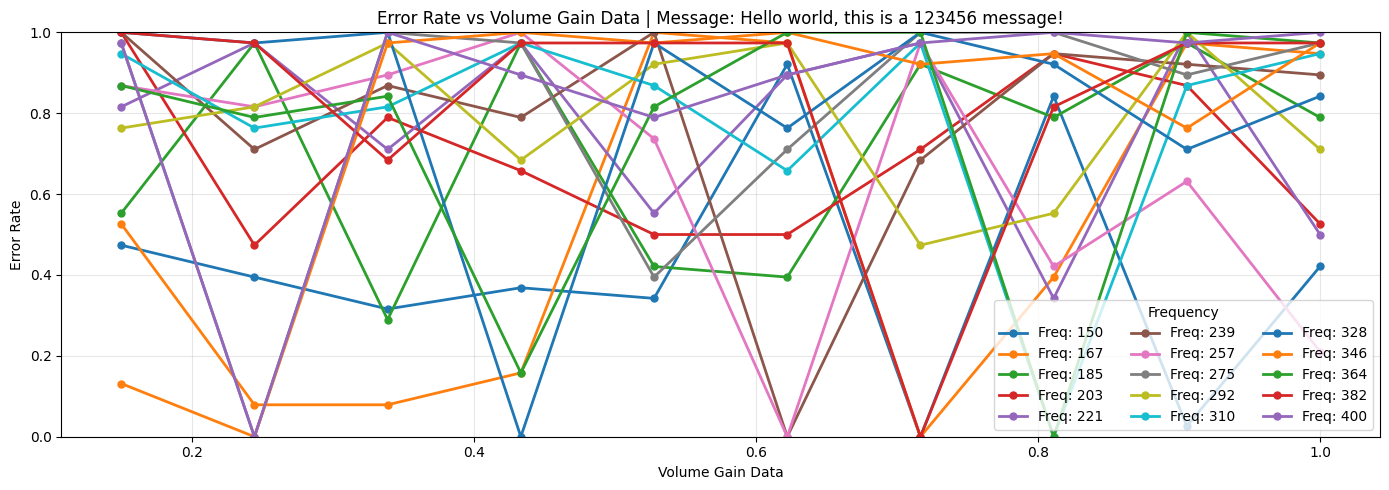

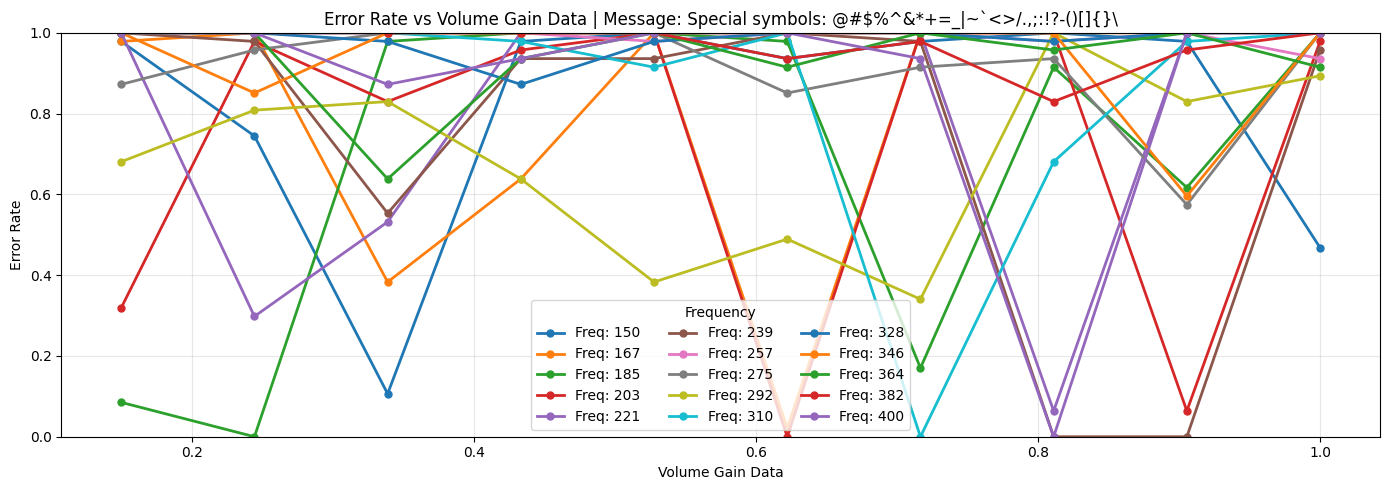

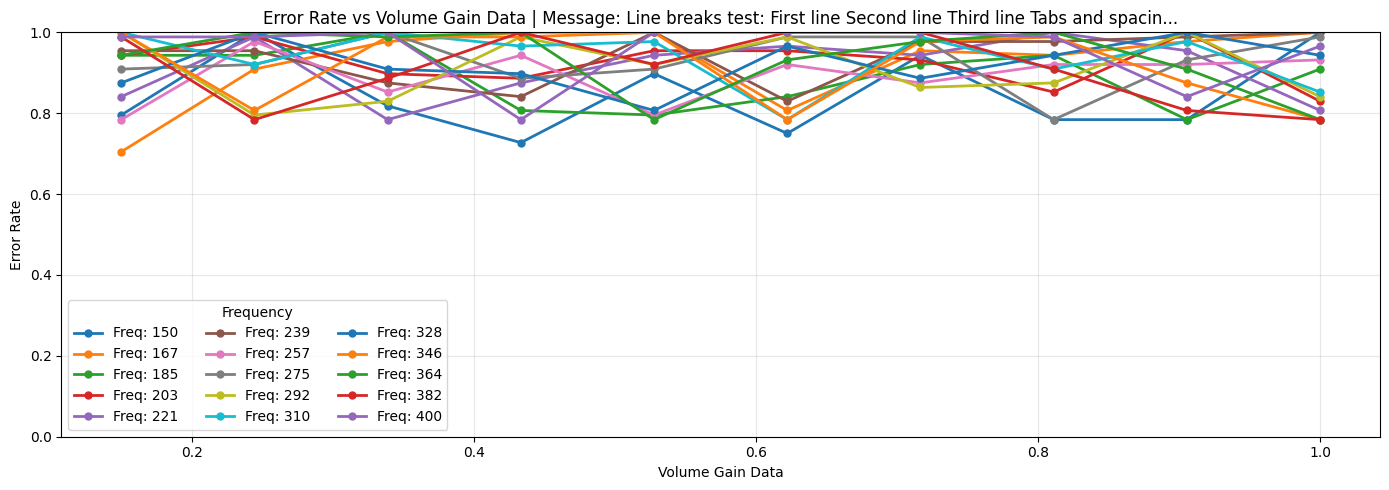

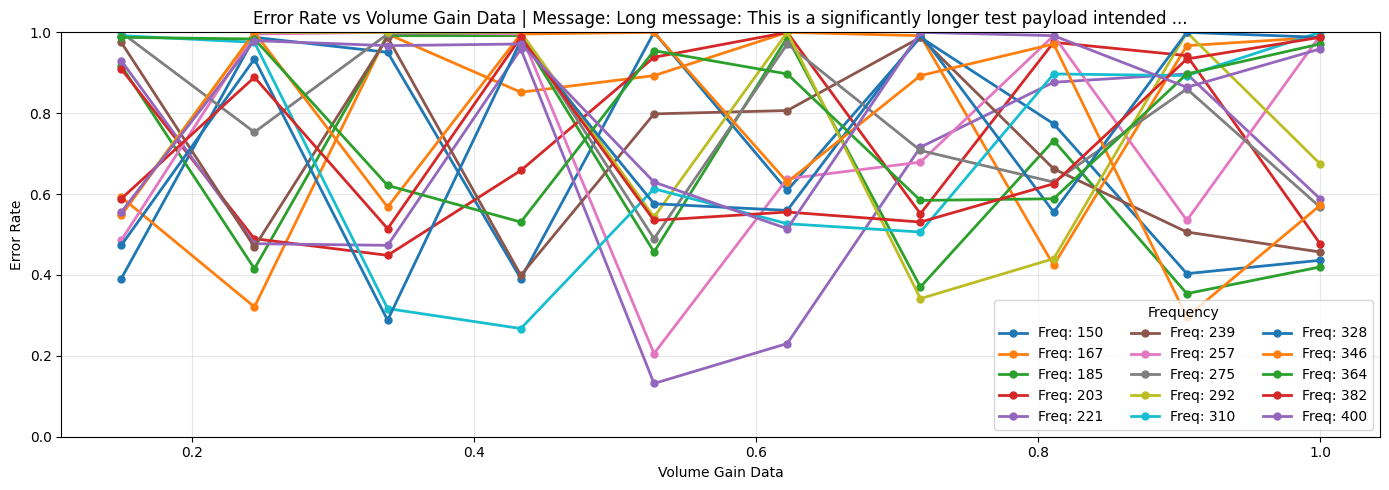

In [5]:
plot_error_rate_vs_volume_by_message(df)

## 3D Interaction: Frequency, Data Volume, and Message
This plot shows interaction between `frequency`, `volume_gain_data`, and message index.
Color and marker size encode `error_rate` (lower is better).

In [6]:
import plotly.express as px

plot_df = prepare_plot_df(df).copy()
plot_df["error_rate_clipped"] = plot_df["error_rate"].clip(0, 1)
plot_df["marker_size"] = 6 + plot_df["error_rate_clipped"] * 18

message_order = plot_df["message_label"].drop_duplicates().tolist()
message_to_idx = {message: idx for idx, message in enumerate(message_order)}
plot_df["message_idx"] = plot_df["message_label"].map(message_to_idx)
plot_df["message_short"] = plot_df["message_label"].map(lambda m: shorten_message(m, 40))

fig = px.scatter_3d(
    plot_df,
    x="frequency",
    y="volume_gain_data",
    z="message_idx",
    color="error_rate",
    size="marker_size",
    symbol="message_short",
    size_max=24,
    color_continuous_scale="Viridis",
    opacity=0.85,
    title="3D Interaction: Frequency vs Data Volume vs Message",
    labels={
        "frequency": "Frequency",
        "volume_gain_data": "Volume Gain Data",
        "message_idx": "Message",
        "error_rate": "Error Rate",
    },
)

fig.update_traces(
    marker={
        "line": {"width": 0.5, "color": "black"},
    }
)

fig.update_layout(
    scene={
        "camera": {"eye": {"x": 1.5, "y": 1.5, "z": 0.9}},
        "zaxis": {
            "tickvals": list(range(len(message_order))),
            "ticktext": [shorten_message(message, 30) for message in message_order],
        },
    },
    margin={"l": 0, "r": 0, "t": 40, "b": 0},
    height=850,
)

fig.show()